In [ ]:
!pip install surprise

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.0/772.0 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.3-cp310-cp310-linux_x86_64.whl size=3095384 sha256=52fcf2129bbdc21bc939cee3167fe5cf3b762e4e5cd19de5238e2631b3081135
  Stored in directory: /root/.cache/pip/wheels/a5/ca/a8/4e28def53797fdc4363ca4af740db15a9c2f1595ebc51fb445
Successfully built scikit-surprise


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# !pip install -U pandasql
# from pandasql import sqldf

### 1. 군집분석


In [ ]:
%cd /content/drive/MyDrive/AI응용_팀플_Lpoint

/content/drive/MyDrive/AI응용_팀플_Lpoint


In [ ]:
# 데이터 로드
df = pd.read_csv('./fin_data_set.csv')
df.head(2)

,customer,Recency,Frequency,Monetory,Purchase_Cycle
0,1,11.0,322,35834150,3.76
1,2,3.0,319,51600290,2.78


In [ ]:
df1 = pd.read_csv('./final_data.csv')
df1.head(2)

,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory
0,1,M,60세이상,Bag&Bag,135,1,186200
1,1,M,60세이상,L.B,277,1,85500


In [ ]:
data1 = df1[['cno','gender','age_grp']].drop_duplicates().reset_index(drop=True)
data_cnt = df1['scls_c_nm'].groupby(df1['cno']).count()
data2 = pd.DataFrame(data_cnt).reset_index(drop=False)

data1.head(2), data2.head(2)

(   cno gender age_grp
 0    1      M   60세이상
 1    2      M   60세이상,
    cno  scls_c_nm
 0    1        100
 1    2         87)

In [ ]:
cust1 = data1.merge(data2, on='cno')

### 고객 특성으로만 군집 분류해보기
1. 성별 one hot encoding
2. 나이 라벨인코딩, Min Max 스케일
3. 거주지 추가해서 확인
4. 상품 구매빈도 추가에서 확인

In [ ]:
# 전처리
# 원핫인코딩
gender1 = pd.get_dummies(cust1[['gender']])
X_data = pd.concat([cust1,gender1],axis=1).drop(['gender'],axis=1)

In [ ]:
def label_at(X_data, li):
  # 라벨인코딩
  from sklearn.preprocessing import LabelEncoder

  # 라벨 인코더 생성
  for i in li:
    encoder = LabelEncoder()
    X_train = list(X_data[f'{i}'].unique())

    # X_train데이터를 이용 피팅하고 라벨숫자로 변환한다
    encoder.fit(X_train)
    X_encoded = encoder.fit_transform(X_data[f'{i}'])
    X_data[f'{i}_le'] = list(X_encoded)
    X_data = X_data.drop([f'{i}'], axis=1)
    return X_data

li = ['age_grp']
X_data = label_at(X_data, li)

In [ ]:
# minmax
# 정규화
from sklearn.preprocessing import MinMaxScaler

# 두 가지 feature를 대상
for i in ['scls_c_nm', 'age_grp_le']:
  data = X_data[[i]]
  scaler = MinMaxScaler()
  data_scale = scaler.fit_transform(data)
  X_data[f'{i}_scale'] = data_scale
  X_data.drop([f'{i}'], axis = 1, inplace=True)

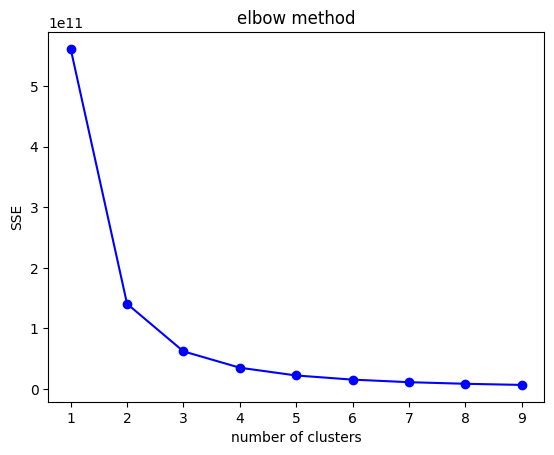

In [ ]:
def elbow(data, length):
    sse = [] # sum of squre error 오차제곱합
    for i in range(1, length):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        # SSE 값 저장
        sse.append(kmeans.inertia_)
    plt.plot(range(1, length), sse, 'bo-')
    plt.title("elbow method")
    plt.xlabel("number of clusters")
    plt.ylabel("SSE")
    plt.show()

elbow(X_data, 10)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

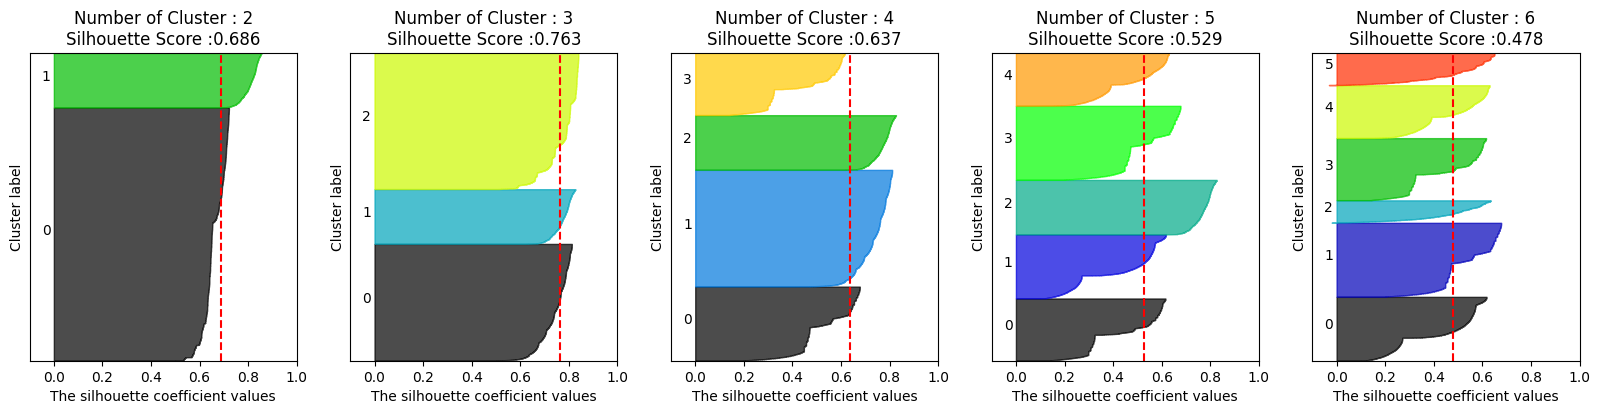

In [ ]:
# 실루엣 기법
def visualize_silhouette(cluster_lists, X_features): 

    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

visualize_silhouette([2, 3, 4, 5, 6], X_data)

In [ ]:
# 군집확인 그리고 decision tree로 군집 특성 확인

def cluster_kmeans(X_data, k):
  from sklearn.cluster import KMeans
  import matplotlib.pyplot as plt
  k = k
  # 그룹 수, random_state 설정
  model = KMeans(n_clusters = k, random_state = 10)
  # 정규화된 데이터에 학습
  model.fit(X_data)
  # 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
  X_data['cluster'] = model.fit_predict(X_data)
  print(X_data['cluster'].value_counts())
  return X_data, model

X_data, model = cluster_kmeans(X_data, 5)

===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================


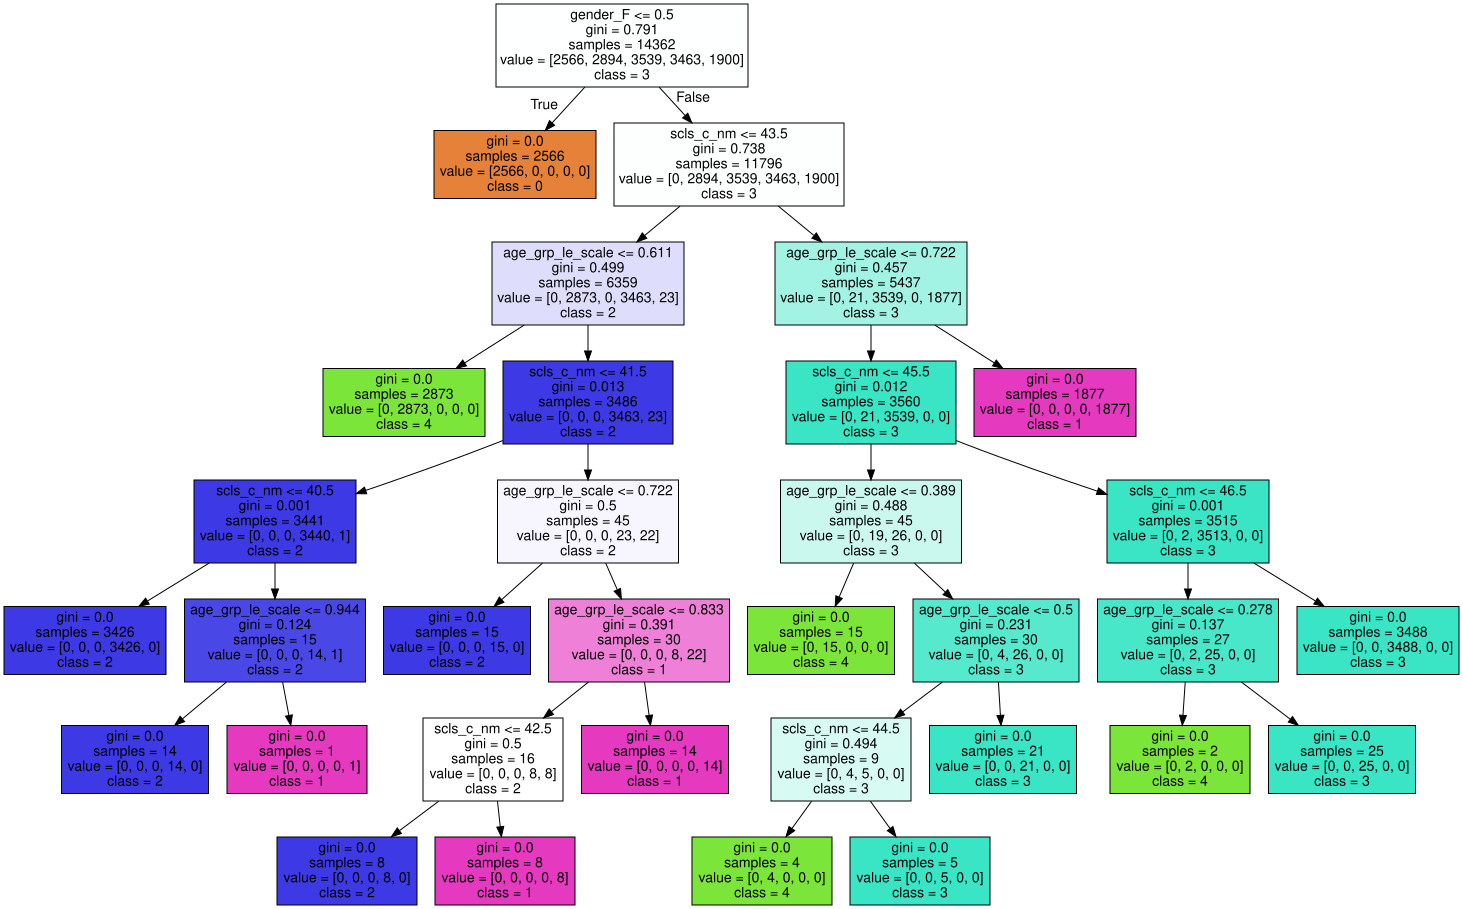

In [ ]:
# DecicionTreeClassifier 생성
X = X_data.drop(['cno','cluster'], axis=1).drop(['scls_c_nm_scale'],axis=1)
c = cust1[['scls_c_nm']]
X = pd.concat( [X, c] , axis=1)
Y = X_data[['cluster']]

def decision_viz(X, Y):
  from sklearn.tree import DecisionTreeClassifier
  from sklearn.model_selection import train_test_split

  dt_clf = DecisionTreeClassifier(random_state=156)

  X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=11)

  # DecisionTreeClassifier 학습
  dt_clf.fit(X_train, y_train)

  from sklearn.tree import export_graphviz

  # export_graphviz( )의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함
  export_graphviz(dt_clf, out_file="tree.dot", class_names = [str(i) for i in list(Y['cluster'].unique())], 
                            feature_names = X.columns, impurity=True, filled=True)
  
  print('===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================')
  import graphviz
  # 위에서 생성된 tree.dot 파일을 Graphiviz 가 읽어서 시각화
  with open("tree.dot") as f:
      dot_graph = f.read()
  return graphviz.Source(dot_graph)


decision_viz(X, Y)

### 거주지 추가

In [ ]:
# 거주지 넣어서
town = pd.read_csv('/content/drive/MyDrive/팀플/Lpoint/raw data/제3회 Big Data Competition-분석용데이터-01.고객DEMO.txt', encoding='CP949')
town = town[['고객번호','거주지역']]

In [ ]:
town.columns=['cno','town']

In [ ]:
X_data1 = X_data.merge(town, on='cno')
df1 = pd.concat([cust1,X_data1], axis=1)

In [ ]:
df2 = label_at(df1, ['town'])
df2.head()

,cno,gender,age_grp,scls_c_nm,cno,gender_F,gender_M,scls_c_nm_scale,age_grp_le_scale,town_x,town_y,town_le
0,1,M,60세이상,100,1,0,1,0.692308,1.0,60.0,60.0,16
1,2,M,60세이상,87,2,0,1,0.601399,1.0,100.0,100.0,25
2,4,F,60세이상,69,4,1,0,0.475524,1.0,16.0,16.0,2
3,5,M,60세이상,33,5,0,1,0.223776,1.0,100.0,100.0,25
4,6,F,60세이상,48,6,1,0,0.328671,1.0,240.0,240.0,27


In [ ]:
df1 = label_at(df1, ['town']) 

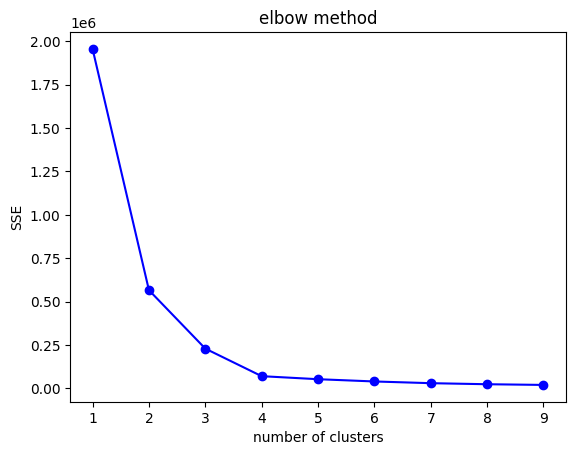

In [ ]:
town_data = df1[['gender_F', 'gender_M', 'age_grp_le_scale', 'town_le']]
elbow(town_data, 10)

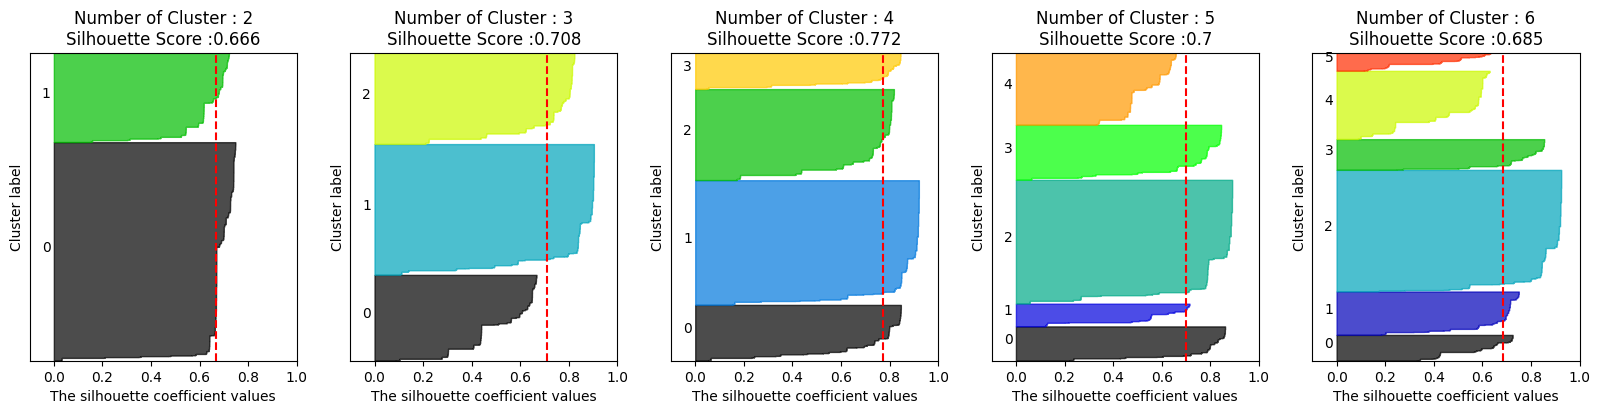

In [ ]:
visualize_silhouette([2, 3, 4, 5, 6], town_data)

In [ ]:
town_data, model = cluster_kmeans(town_data, 4)

3    7279
1    5316
0    3253
2    2105
Name: cluster, dtype: int64


In [ ]:
town_data.columns

Index(['gender_F', 'gender_M', 'age_grp_le_scale', 'town_le', 'cluster'], dtype='object')

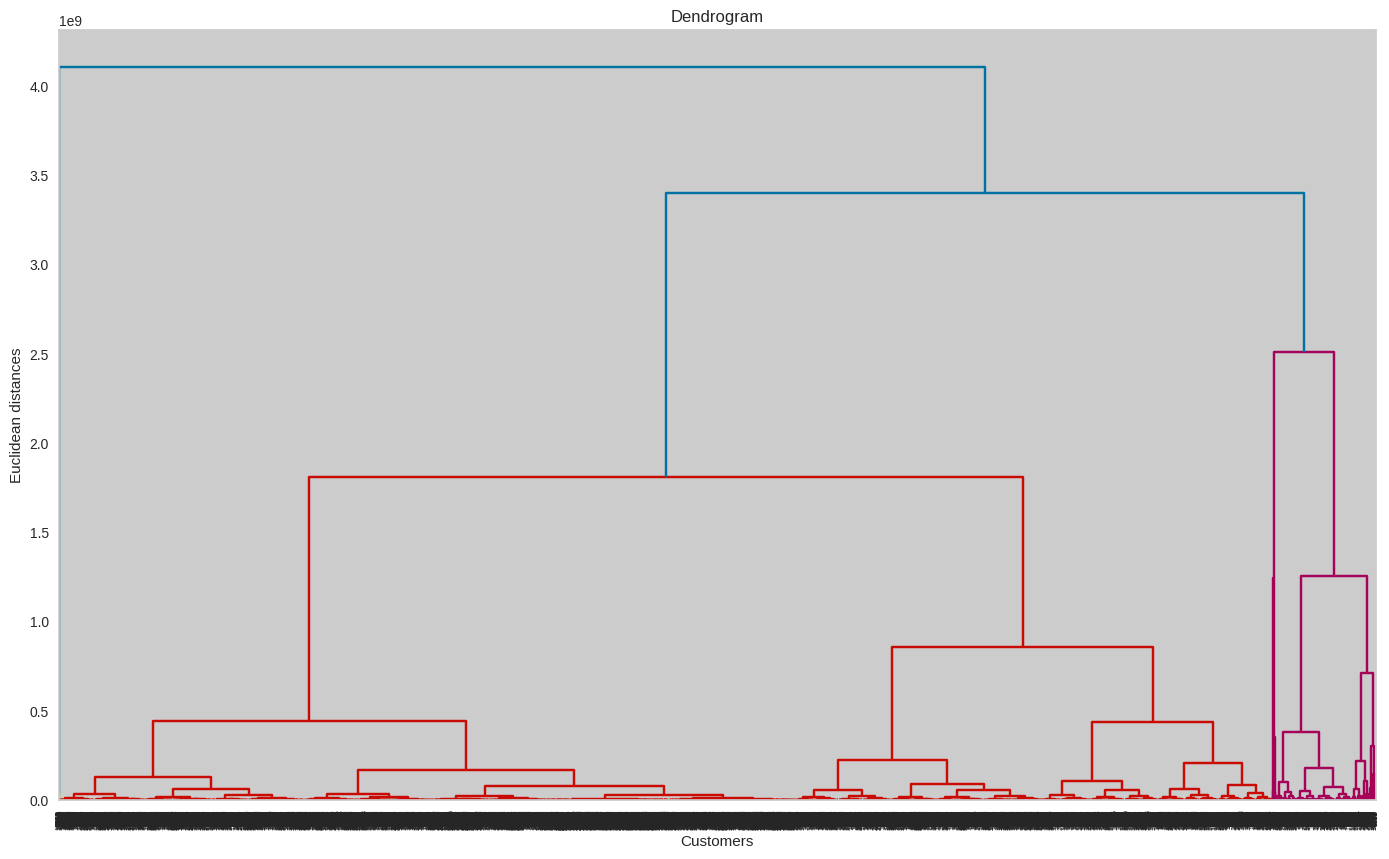

In [ ]:
X = df.iloc[:,[1,2,3]].values
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy
plt.figure(figsize=(17,10))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================


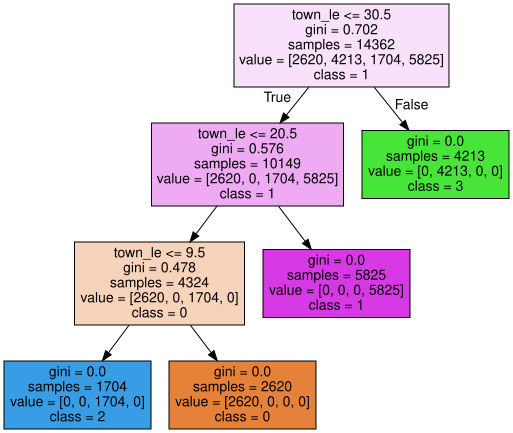

In [198]:
X = town_data.drop(['cluster'],axis=1)
Y = town_data[['cluster']]
decision_viz(X, Y)

### 기타

In [ ]:
# 고객 군집하기
# 고객번호 group by / scls_c_nm cnt
# pivot 만들어서 count sum avg
pi1 = df1.pivot(index='cno',columns='scls_c_nm',values='Monetory').fillna(0)
df_pi1 = pd.DataFrame( pi1.sum(axis=1), columns=['Monetory_sum'])
pi2 = df1.pivot(index='cno',columns='scls_c_nm',values='Frequency').fillna(0)
pi2_= pi2.sum(axis=1)
df_pi2 = pd.DataFrame(pi2_, columns=['Frequency_sum'])
pi3 = df1.pivot(index='cno',columns='scls_c_nm',values='Recency').fillna(0)
df_pi3= pd.DataFrame(pi3.sum(axis=1), columns=['Recency_sum'])

In [ ]:
mer1= pd.merge(df_pi1.reset_index(),df_pi3.reset_index())
mer2= pd.merge(df_pi2.reset_index(),mer1)

In [ ]:
mer2.head()

,cno,Frequency_sum,Monetory_sum,Recency_sum
0,1,397.0,32472280.0,16551.0
1,2,491.0,53409030.0,12445.0
2,4,333.0,5895570.0,7458.0
3,5,200.0,4929370.0,2458.0
4,6,185.0,8536290.0,6123.0


In [ ]:
# 정규화
from sklearn.preprocessing import MinMaxScaler

# 두 가지 feature를 대상
for i in ['Frequency_sum', 'Monetory_sum', 'Recency_sum']:
  data = mer2[[i]]
  scaler = MinMaxScaler()
  data_scale = scaler.fit_transform(data)
  mer2[f'{i}_scale'] = data_scale

In [ ]:
# 위 데이터로만 군집분류 해보기
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
k = 5
# 그룹 수, random_state 설정
model = KMeans(n_clusters = k, random_state = 10)
X = mer2.drop(['cno'], axis=1)
# 정규화된 데이터에 학습
model.fit(X)
# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
mer2['cluster'] = model.fit_predict(X)

In [ ]:
mer2.head()

,cno,Frequency_sum,Monetory_sum,Recency_sum,cluster,Frequency_sum_scale,Monetory_sum_scale,Recency_sum_scale
0,1,397.0,32472280.0,16551.0,0,0.276536,0.014846,0.716729
1,2,491.0,53409030.0,12445.0,0,0.342179,0.024418,0.538911
2,4,333.0,5895570.0,7458.0,1,0.231844,0.002695,0.322940
3,5,200.0,4929370.0,2458.0,1,0.138966,0.002253,0.106405
4,6,185.0,8536290.0,6123.0,1,0.128492,0.003902,0.265125


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# 왼쪽은 scaling 적용 X 데이터, 오른쪽은 scaling 적용 O 데이터
# 순서대로 single linkage, complete linkage, average linkage, centroid linkage, ward linkage 적용해보았다.
# 거리를 기준으로 proximity matrix를 만들고 이에 따라 cluster를 키워 나가는데,
# 군집 간 거리를 측정하는 방식이 달라지니 군집화가 이루어진 결과도 확연히 차이가 났다.

X = mer2[['Frequency_sum_scale','Monetory_sum_scale','Recency_sum_scale']]

fig, axes = plt.subplots(nrows=len(X), ncols=2, figsize=(16, 35))
for i in range(len(X)):
    for j in range(len(data)):
        hierarchical_single = linkage(data[j], method=X[i])
        dn = dendrogram(hierarchical_single, ax=axes[i][j])
        axes[i][j].title.set_text(X[i])
plt.show()

In [ ]:
# 위의 dendrogram 결과 중 average가 비교적 균일하게 군집화가 이루어진 것 같아 
# cluster가 5가 되도록 클러스터링

from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=5, linkage='average')
labels = agg_clustering.fit_predict(X)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d') 

x = X['Frequency_sum_scale']
y = X['Monetory_sum_scale)']
z = X['Recency_sum_scale']
ax.scatter(x, y, z, c = labels, s= 20, alpha=0.5, cmap='rainbow')

In [ ]:
from sklearn.cluster import KMeans

# k에 따라 inertia_(군집 내 거리제곱합의 합)이 어떻게 변하는 지 시각화
def change_n_clusters(n_clusters, data):
    sum_of_squared_distance = []
    for n_cluster in n_clusters:
        kmeans = KMeans(n_clusters=n_cluster)
        kmeans.fit(mall_df)
        sum_of_squared_distance.append(kmeans.inertia_)
        
    plt.figure(1 , figsize = (12, 6))
    plt.plot(n_clusters , sum_of_squared_distance , 'o')
    plt.plot(n_clusters , sum_of_squared_distance , '-' , alpha = 0.5)
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')


In [ ]:
n_clusters = 3
mall_df = mer2.copy

change_n_clusters(n_clusters, mall_df)

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

eigh = NearestNeighbors(n_neighbors=5)
neigh.fit(mall_df)
distances, indices = neigh.kneighbors(mall_df) # 각 개체마다 거리를 계산해서 가까운 거리의 5개와 그 떄의 index 반환

# 4-dist를 plotting 해보기
# 저 빨간점에서 급격히 4-dist가 급증하였다 -> 우리는 이 때의 distance인 18을 eps로, 4를 minpts로 잡고 DBSCAN을 진행해보도록 하자.
plt.figure(figsize=(12, 6))
plt.plot(np.sort(distances[:, 4]))
plt.axvline(188, 0, 2, ls='--')
plt.axhline(18, 0, 200, ls='--')

print(np.sort(distances[:, 4])[188])

In [ ]:
dbscan = DBSCAN(eps=18, min_samples=4) # scaling 하지 않은 데이터로 DBSCAN 학습
dbscan.fit(mall_df)

print(np.unique(dbscan.labels_))

plt.figure(figsize=(20, 6))
plt.subplot(131)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=mall_df, hue=dbscan.labels_, palette='coolwarm')
plt.subplot(132)
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=mall_df, hue=dbscan.labels_, palette='coolwarm')
plt.subplot(133)
sns.scatterplot(x='Age', y='Annual Income (k$)', data=mall_df, hue=dbscan.labels_, palette='coolwarm')

# DBSCAN은 밀도가 급격히 변할 때 군집을 잘 인식하지 못하는데, 이 데이터가 그러하여 군집을 잘 찾지 못한 것 같다.
# (촘촘한 밀도를 고려하지 못하고 전체를 하나의 군집으로 인식)
# 실제로 DBSCAN한 결과 1개의 cluster만 형성되었다. (-1은 noise point이다.)
# 이 데이터에는 DBSCAN이 적합하지 않은 것으로 예상된다.

In [ ]:
# 고객 성별, 연령
df_info = df1[['cno','gender','age_grp']].copy()
df_info.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=False)

In [ ]:
df_info.head(2)

,cno,gender,age_grp
0,1,M,60세이상
100,2,M,60세이상


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 라벨 인코더 생성
encoder = LabelEncoder()
items = list(df_info['gender'].unique())
# X_train데이터를 이용 피팅하고 라벨숫자로 변환한다
encoder.fit(items)
df_info['gender_le'] = encoder.transform(df_info['gender'])

encoder = LabelEncoder()
items = list(df_info['age_grp'].unique())
# X_train데이터를 이용 피팅하고 라벨숫자로 변환한다
encoder.fit(items)
df_info['age_grp_le'] = encoder.transform(df_info['age_grp'])

In [ ]:
df_info.head(2)

,cno,gender,age_grp,gender_le,age_grp_le
0,1,M,60세이상,1,9
100,2,M,60세이상,1,9


#### Kmeans

In [ ]:
# 모델
from sklearn.cluster import KMeans

k = 3

# 그룹 수, random_state 설정
model = KMeans(n_clusters = k, random_state = 10)

# 정규화된 데이터에 학습
model.fit(data_scale)

# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = model.fit_predict(data_scale)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, 'Annual Income (k$)'], df.loc[df['cluster'] == i, 'Spending Score (1-100)'], 
                label = 'cluster ' + str(i))

plt.legend()
plt.title('K = %d results'%k , size = 15)
plt.xlabel('Annual Income', size = 12)
plt.ylabel('Spending Score', size = 12)
plt.show()

#### 평가


In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(data_scale)

In [ ]:
## 군집특성 확인


#### DBSCAN
